In [1]:
import snappy
import networkx as nx
from knot_graphs import *
from khovanov import *

import pdb

# We want to identify pinch moves (planar, non-orientable band moves)

In [2]:
K = snappy.Link("T(2,3)")

In [3]:
K.view()
%gui tk

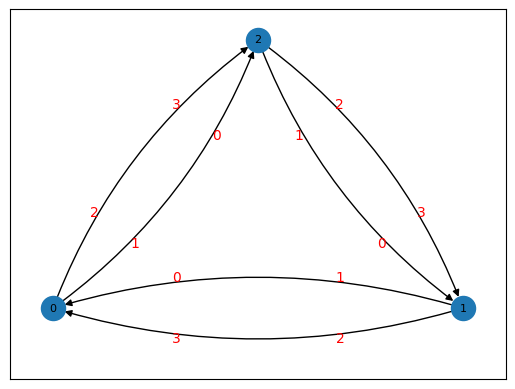

In [4]:
draw_adjacency_graph(K, rad_increment=0.15)

In [5]:
def planar_band_targets(edge, planar_emb):
    face_nodes = planar_emb.traverse_face(edge[0], edge[1])
    return [(face_nodes[i], face_nodes[(i+1) % len(face_nodes)]) for i in range(len(face_nodes))]

In [6]:
def list_planar_arc_pairs(knot):
    graph = adjacency_graph(knot)
    is_planar, planar_emb = nx.check_planarity(graph)
    if not is_planar:
        return "Knot graph isn't planar!"

    planar_band_arcs = {}
    for e in planar_emb.edges():
        planar_band_arcs[e] = planar_band_targets(e, planar_emb)[1:] # all other edges in the right face associated to e
    return planar_band_arcs

In [7]:
list_planar_arc_pairs(K)

{(0, 1): [(1, 2), (2, 0)],
 (0, 2): [(2, 1), (1, 0)],
 (1, 0): [(0, 2), (2, 1)],
 (1, 2): [(2, 0), (0, 1)],
 (2, 1): [(1, 0), (0, 2)],
 (2, 0): [(0, 1), (1, 2)]}

### TODO - there should be nine total planar arc-pairs
(18 entries in above dict since each band is identified by both of its ends)
<div>
<center>
    <img src="images/pinch_sketch.jpg" width="800"/>
</center>
</div>

What about cases like the arc 2 to arc 5 band?

Its orientable band is twisted, so is the negative twist also orientable?

Are both the negative twist and the 0 twist non-orientable?

### TODO - identify which twists are non-orientable (hence a pinch move) for each planar band (arc pair) above

Write a function that takes a pair of arcs and returns which twist numbers give non-orientable bands.

### Idea: orientable bands yield links, non-orientable bands yield knots.
- Pick any adjacent pair of strands
- Try -1, 0, 1-twist bands on them
    - Take complement + identify resulting manifold using `snappy.Manifold.identify`
    - If complement is a link then the band is orientable.
    - If complement is a knot then the band is non-orientable.

In [8]:
def find_pinch_move(K):
    graph = adjacency_graph(K)
    planar_arc_pairs = list_planar_arc_pairs(K)
    print(graph.edges())

    #take first pair of adjacent arcs
    arc0, adj_arcs = list(planar_arc_pairs.items())[0]
    arc1 = adj_arcs[0]
    for twist in [-1,0,1]:
        # get (crossing, strand)'s from edges' (crossing, crossing) in arc1/arc2
        c0 = arc0[0]
        c1 = arc1[0]

        ed0 = graph.get_edge_data(arc0[0], arc0[1])
        if ed0 is None:
            ed0 = graph.get_edge_data(arc0[1], arc0[0])
        if ed0 is None:
            print(f'arc0 {arc0} not found in graph')
            continue
        edge0 = list(ed0.values())[0]
        s0 = edge0['tail_strand']

        ed1 = graph.get_edge_data(arc1[0], arc1[1])
        if ed1 is None:
            ed1 = graph.get_edge_data(arc1[1], arc1[0])
        if ed1 is None:
            print(f'arc1 {arc1} not found in graph')
            continue
        edge1 = list(ed1.values())[0]
        s1 = edge1['tail_strand']

        K_khovanov_link = Link(K.PD_code())
        try:
            S = Cobordism(K_khovanov_link)
            
            # do the band move
            S.band_move(twist, (c0, s0), (c1, s1))

            # identify
            K_prime = S.links[-1]
            snappy_K_prime = snappy.Link(K_prime.PD_code())
            
            #writhe_prime = snappy_K_prime.writhe()
            #normal_euler = writhe_prime - writhe
            #es.append(normal_euler)

            complement = snappy_K_prime.exterior()
            result = complement.identify(extends_to_link=True)

            if len(result) == 0:
                print(f'band ({twist}, ({c0},{s0}), ({c1},{s1})) could not be identified')
            else:
                print(result)
        except Exception as e:
            print(f'band ({twist}, ({c0},{s0}), ({c1},{s1})) threw an error: \n {e}')
            #pdb.set_trace()
            continue

In [9]:
find_pinch_move(K)

[(0, 2), (0, 2), (1, 0), (1, 0), (2, 1), (2, 1)]
band (-1, (0,2), (1,2)) threw an error: 
 maximum recursion depth exceeded
band (0, (0,2), (1,2)) threw an error: 
 min() iterable argument is empty
band (1, (0,2), (1,2)) threw an error: 
 maximum recursion depth exceeded
